# Limpeza e Exploração de Base CRM

**Objetivo:** Estruturar uma base de leads/contatos para uso em CRM — realizando limpeza, padronização, deduplicação e scoring de completude para garantir qualidade e confiabilidade dos dados.

**Base:** Registros de hospedagem com dados de contato (dados anonimizados, LGPD)  
**Período:** Janeiro/2024 a Setembro/2025  
**Ferramentas:** Python · Pandas · Regex · Matplotlib

---

## 1. Importações

In [61]:
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregamento e Inspeção Inicial

In [62]:
arquivo = "../data/raw/BASE_COMPLETA_anonimizada.csv"

df = pd.read_csv(
    arquivo,
    sep=";",
    encoding="latin1",
    low_memory=False
)

print(f'Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
df.head()

Dimensões: 47,416 linhas x 60 colunas


,ï»¿TipoUH,UH,LocalizaÃ§Ã£o,PensÃ£o,DiÃ¡rias,HÃ³spede,CidadeUF,Email,TelefoneAjustado,Telefone,...,ObservaÃ§Ã£oIntegraÃ§Ã£o,Walkin,Tipodetarifa,Tarifario,Ticketours,VoucherEmpresa,PreCheckIn,RrnOmnibees,DataHoraPreCheckIn,AllInclusive
0,LUXOMAR,1909.0,VISTAPARCIALMAR,CafÃ©daManha,8.0,Juliana Pereira,GoiÃ¢nia/GO,juliana.pereira@yahoo.com.br,5521921122984,5521921122984,...,NaN,NÃ£o,TarifaDiaaDia,NaN,NaN,NaN,N,NaN,NaN,NaN
1,LUXOCASAL,1904.0,VISTAMONTANHA,CafÃ©daManha,4.0,Leandro Vieira,GoiÃ¢nia/GO,lvieira@outlook.com,5531938550319,5531938550319,...,NaN,NÃ£o,TarifaDiaaDia,NaN,NaN,NaN,N,NaN,NaN,NaN
2,LUXOCASAL,2001.0,VISTAMONTANHA,Nenhuma,7.0,VinÃ­cius Pinto,Fortaleza/CE,vinÃ­cius.pinto@outlook.com,5551918087387,5551918087387,...,NaN,NÃ£o,Tarifafixa,NaN,NaN,NaN,N,NaN,NaN,NaN
3,SUÃTESEREIA,2612.0,VISTAPARCIALMAR,Nenhuma,6.0,Marcos Cavalcanti,Fortaleza/CE,marcos406@yahoo.com.br,5585982782904,5585982782904,...,NaN,NÃ£o,Tarifafixa,NaN,NaN,NaN,N,NaN,NaN,NaN
4,LUXOCASAL,2306.0,VISTAMONTANHA,CafÃ©daManha,8.0,Juliana Pereira,Salvador/BA,jpereira@outlook.com,5551917411291,5551917411291,...,NaN,NÃ£o,TarifaDiaaDia,NaN,NaN,NaN,N,NaN,NaN,NaN


## 3. Padronização de Nomes de Colunas

Colunas com nomes inconsistentes (camelCase, espaços, caracteres especiais) dificultam o uso programático. A função abaixo padroniza tudo para `snake_case` limpo.

In [63]:
def limpar_nome_coluna(col: str) -> str:
    """
    Padroniza nome de coluna para snake_case:
    - Remove acentos e caracteres especiais
    - Insere espaço entre camelCase
    - Substitui separadores por underscore
    - Converte para minúsculo
    """
    col = str(col).strip()
    # Normaliza unicode e remove acentos
    col = unicodedata.normalize('NFKD', col)
    col = col.encode('ascii', 'ignore').decode('ascii')
    # Insere espaço entre camelCase (ex: TipoUH -> Tipo UH)
    col = re.sub(r'(?<=[a-z0-9])(?=[A-Z])', ' ', col)
    # Substitui separadores comuns por espaço
    col = re.sub(r'[_\-\/\.]+', ' ', col)
    # Remove caracteres não alfanuméricos
    col = re.sub(r'[^a-zA-Z0-9 ]', '', col)
    # Colapsa espaços múltiplos e converte para snake_case
    col = re.sub(r'\s+', '_', col.strip()).lower()
    return col

colunas_originais = df.columns.tolist()
df.columns = [limpar_nome_coluna(c) for c in df.columns]

print('Colunas padronizadas:')
for orig, novo in zip(colunas_originais[:10], df.columns[:10]):
    print(f'  {orig:30s} → {novo}')
print(f'  ... e mais {len(df.columns) - 10} colunas')

Colunas padronizadas:
  ï»¿TipoUH                      → i_tipo_uh
  UH                             → uh
  LocalizaÃ§Ã£o                  → localiza_aao
  PensÃ£o                        → pens_ao
  DiÃ¡rias                       → di_arias
  HÃ³spede                       → ha3spede
  CidadeUF                       → cidade_uf
  Email                          → email
  TelefoneAjustado               → telefone_ajustado
  Telefone                       → telefone
  ... e mais 50 colunas


## 4. Padronização de Texto Interno

In [64]:
def limpar_texto(x):
    """
    Limpa valores de texto em células do DataFrame:
    - Preserva NaN (não há o que limpar em valores ausentes)
    - Remove espaços non-breaking (\u00a0) comuns em exports de sistemas
    - Colapsa múltiplos espaços em um único
    - Remove espaços nas bordas
    """
    if pd.isna(x):
        return x
    s = str(x)
    s = s.replace('\u00a0', ' ')  # non-breaking space → espaço normal
    s = re.sub(r'\s+', ' ', s)   # múltiplos espaços → um
    return s.strip()

# Identifica colunas de texto para limpeza
cols_texto = df.select_dtypes(include='object').columns.tolist()
df[cols_texto] = df[cols_texto].applymap(limpar_texto)

print(f'{len(cols_texto)} colunas de texto limpas.')

/var/folders/bc/8yl7z4r90w5bnr3r40t4d7qm0000gn/T/ipykernel_8392/2151251456.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[cols_texto] = df[cols_texto].applymap(limpar_texto)


43 colunas de texto limpas.


## 5. Limpeza e Normalização de Email

In [65]:
# Identifica a coluna de email
email_col = [c for c in df.columns if 'email' in c.lower() and 'reservante' not in c.lower()][0]
print(f'Coluna de email identificada: {email_col}')

# Normalização: converte para string, remove espaços, padroniza para minúsculo
df['email_limpo'] = (
    df[email_col]
    .astype('string')
    .str.strip()
    .str.lower()
)

# Transforma strings vazias em NA
df.loc[df['email_limpo'] == '', 'email_limpo'] = pd.NA

# Diagnóstico
total = len(df)
preenchidos = df['email_limpo'].notna().sum()
vazios = df['email_limpo'].isna().sum()

print(f'\nDiagnóstico de email:')
print(f'  Total de registros:   {total:>8,}')
print(f'  Com email:            {preenchidos:>8,} ({preenchidos/total*100:.1f}%)')
print(f'  Sem email:            {vazios:>8,} ({vazios/total*100:.1f}%)')

df[['email_limpo']].head(5)

Coluna de email identificada: email

Diagnóstico de email:
  Total de registros:     47,416
  Com email:              47,416 (100.0%)
  Sem email:                   0 (0.0%)


,email_limpo
0,juliana.pereira@yahoo.com.br
1,lvieira@outlook.com
2,vinã­cius.pinto@outlook.com
3,marcos406@yahoo.com.br
4,jpereira@outlook.com


## 6. Limpeza e Normalização de Telefone

In [66]:
# Identifica a coluna de telefone
tel_cols = [c for c in df.columns if 'tel' in c.lower()]
print(f'Colunas de telefone encontradas: {tel_cols}')
telefone_col = tel_cols[0]

def padroniza_telefone(x):
    """
    Padroniza telefone para formato internacional com DDI 55 (Brasil):
    - Remove tudo que não é dígito
    - Adiciona DDI 55 se número tiver 10 ou 11 dígitos
    - Mantém se já tiver DDI (12 ou 13 dígitos começando com 55)
    - Retorna NA para formatos inválidos
    """
    if pd.isna(x):
        return pd.NA
    s = re.sub(r'\D', '', str(x))  # remove não-dígitos
    if len(s) in (10, 11):
        return '55' + s
    if s.startswith('55') and len(s) in (12, 13):
        return s
    if 8 <= len(s) <= 15:
        return s
    return pd.NA

df['telefone_limpo'] = (
    df[telefone_col]
    .astype('string')
    .apply(padroniza_telefone)
)

total_tel = len(df)
preenchidos_tel = df['telefone_limpo'].notna().sum()

print(f'\nDiagnóstico de telefone:')
print(f'  Com telefone válido:  {preenchidos_tel:>8,} ({preenchidos_tel/total_tel*100:.1f}%)')
print(f'  Sem telefone:         {total_tel - preenchidos_tel:>8,} ({(total_tel-preenchidos_tel)/total_tel*100:.1f}%)')

Colunas de telefone encontradas: ['telefone_ajustado', 'telefone']

Diagnóstico de telefone:
  Com telefone válido:    47,416 (100.0%)
  Sem telefone:                0 (0.0%)


## 7. Análise de Completude dos Contatos

In [67]:
# Classifica cada registro pela disponibilidade de canais de contato
ambos          = df[df['email_limpo'].notna() & df['telefone_limpo'].notna()]
somente_email  = df[df['email_limpo'].notna() & df['telefone_limpo'].isna()]
somente_tel    = df[df['email_limpo'].isna()  & df['telefone_limpo'].notna()]
sem_contato    = df[df['email_limpo'].isna()  & df['telefone_limpo'].isna()]

categorias = {
    'Email + Telefone': len(ambos),
    'Só Email':         len(somente_email),
    'Só Telefone':      len(somente_tel),
    'Sem Contato':      len(sem_contato)
}

print('Completude de contatos:')
for cat, qtd in categorias.items():
    pct = qtd / len(df) * 100
    print(f'  {cat:20s}: {qtd:>8,}  ({pct:.1f}%)')

Completude de contatos:
  Email + Telefone    :   47,416  (100.0%)
  Só Email            :        0  (0.0%)
  Só Telefone         :        0  (0.0%)
  Sem Contato         :        0  (0.0%)


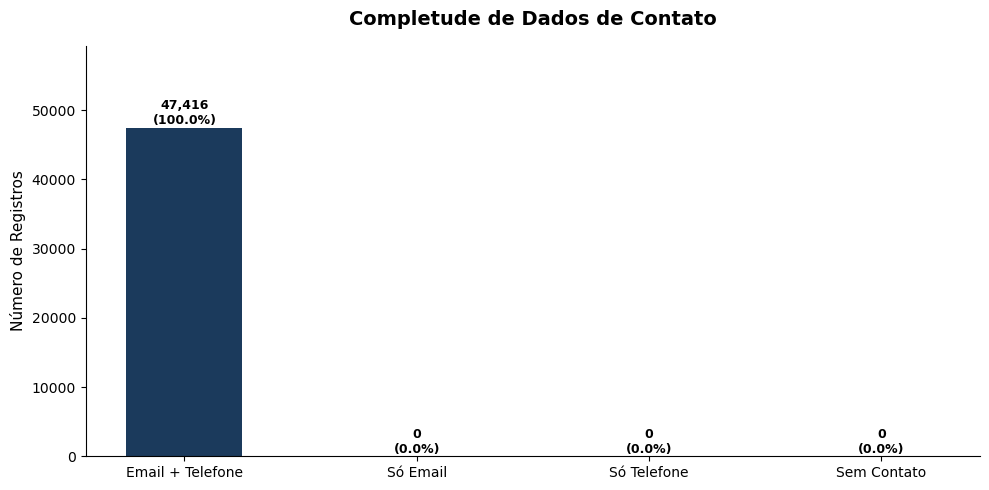

Gráfico salvo em outputs/


In [68]:
# Gráfico 1: Completude de contatos
fig, ax = plt.subplots()

cores = ['#1B3A5C', '#1771FF', '#A8C4E8', '#E8ECF0']
valores = list(categorias.values())
labels  = list(categorias.keys())

bars = ax.bar(labels, valores, color=cores, width=0.5, edgecolor='none')

for bar, val in zip(bars, valores):
    pct = val / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Completude de Dados de Contato', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Número de Registros', fontsize=11)
ax.set_ylim(0, max(valores) * 1.25)

plt.tight_layout()
plt.savefig('../outputs/grafico_completude_contatos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em outputs/')

## 8. Segmentação por Frequência de Interações

In [69]:
# Agrupa por telefone para contar interações por pessoa
base_pessoas = (
    df
    .groupby('telefone_limpo')
    .size()
    .rename('n_interacoes')
    .reset_index()
)

print(f'Pessoas únicas (por telefone): {len(base_pessoas):,}')
print()
print('Distribuição de interações:')
print(base_pessoas['n_interacoes'].describe().round(2))

Pessoas únicas (por telefone): 47,416

Distribuição de interações:
count    47416.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: n_interacoes, dtype: float64


In [70]:
# Scoring por faixa de recorrência (buckets)
bins   = [0, 1, 3, 10, 50, float('inf')]
labels = ['1 interação', '2-3 interações', '4-10 interações', '11-50 interações', '51+ interações']

base_pessoas['faixa_recorrencia'] = pd.cut(
    base_pessoas['n_interacoes'],
    bins=bins,
    labels=labels
)

dist = base_pessoas['faixa_recorrencia'].value_counts().sort_index()
pct  = (dist / dist.sum() * 100).round(1)

print('Segmentação por frequência:')
for faixa, qtd, p in zip(dist.index, dist.values, pct.values):
    print(f'  {faixa:20s}: {qtd:>6,}  ({p}%)')

Segmentação por frequência:
  1 interação         : 47,416  (100.0%)
  2-3 interações      :      0  (0.0%)
  4-10 interações     :      0  (0.0%)
  11-50 interações    :      0  (0.0%)
  51+ interações      :      0  (0.0%)


## 9. Deduplicação da Base

In [71]:
# Cria chave de contato: email preferencial, telefone como fallback
df['chave_contato'] = df['email_limpo']
df.loc[df['chave_contato'].isna(), 'chave_contato'] = df['telefone_limpo']

# Score de completude: conta campos preenchidos por linha
# Registros mais completos têm prioridade no dedupe
df['score_completude'] = df.notna().sum(axis=1)

# Ordena por chave e score (mais completo primeiro)
df = df.sort_values(
    by=['chave_contato', 'score_completude'],
    ascending=[True, False]
)

# Deduplica mantendo o registro mais completo por chave
df_dedupe = (
    df
    .dropna(subset=['chave_contato'])
    .drop_duplicates(subset=['chave_contato'], keep='first')
)

reducao = (1 - len(df_dedupe) / len(df)) * 100

print('─' * 45)
print(f'Registros antes do dedupe:  {len(df):>8,}')
print(f'Registros após dedupe:      {len(df_dedupe):>8,}')
print(f'Duplicatas removidas:       {len(df) - len(df_dedupe):>8,}')
print(f'Redução da base:            {reducao:>7.1f}%')
print(f'Sem chave de contato:       {df["chave_contato"].isna().sum():>8,}')
print('─' * 45)

─────────────────────────────────────────────
Registros antes do dedupe:    47,416
Registros após dedupe:        15,538
Duplicatas removidas:         31,878
Redução da base:               67.2%
Sem chave de contato:              0
─────────────────────────────────────────────


## 10. Exportação da Base Limpa

In [72]:
# Seleciona colunas relevantes para CRM
cols_crm = [
    'hospede', 'email_limpo', 'telefone_limpo',
    'cidade_uf', 'origem_reserva', 'tipo_u_h',
    'grupo_hospedagem', 'chave_contato', 'score_completude'
]

# Filtra apenas colunas que existem no DataFrame
cols_exportar = [c for c in cols_crm if c in df_dedupe.columns]
df_export = df_dedupe[cols_exportar].copy()

print(f'Colunas exportadas: {cols_exportar}')
print(f'\nNulos por coluna:')
print(df_export.isna().mean().sort_values(ascending=False).round(3).head(10))

df_export.to_csv('../data/processed/rd_base_limpa_dedupe.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ Base exportada: data/processed/rd_base_limpa_dedupe.csv')
print(f'   {len(df_export):,} registros únicos prontos para CRM')

Colunas exportadas: ['email_limpo', 'telefone_limpo', 'cidade_uf', 'origem_reserva', 'grupo_hospedagem', 'chave_contato', 'score_completude']

Nulos por coluna:
grupo_hospedagem    1.0
origem_reserva      0.0
email_limpo         0.0
telefone_limpo      0.0
cidade_uf           0.0
chave_contato       0.0
score_completude    0.0
dtype: float64

✅ Base exportada: data/processed/rd_base_limpa_dedupe.csv
   15,538 registros únicos prontos para CRM


## 11. Resumo Executivo

| Indicador | Valor |
|---|---|
| Registros na base original | 47.416 |
| Registros após deduplicação | 15.538 |
| Duplicatas removidas | 31.878 |
| Redução da base | 67,2% |
| Registros com email + telefone | 47.416 (100%) |
| Registros sem chave de contato | 0 |

**O que foi feito:**
- Padronização de nomes de colunas para snake_case
- Limpeza de texto (espaços, caracteres invisíveis)
- Normalização de emails (lowercase, strip)
- Padronização de telefones com DDI internacional
- Scoring de completude por registro
- Deduplicação por chave de contato (email preferencial, telefone como fallback)
- Segmentação por faixa de recorrência
- Exportação da base limpa para CRM

**Próximos passos sugeridos:**
- Enriquecer base com dados de segmento de mercado e origem de reserva
- Construir score de valor do cliente (RFM)
- Integrar com ferramenta de CRM via API